In [4]:
import torch
from torch.nn import functional as F

In [5]:
torch.manual_seed(1337)
B,T,C = 4,8,2
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

### trivial loop

In [6]:
xbow = torch.zeros((B,T,C))     # Bag Of Words
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1]      # (t, C)
        xbow[b,t] = torch.mean(xprev, 0)

In [7]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [8]:
xbow[0]     # correct means

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

### toy example

In [9]:
torch.manual_seed(42)
a = torch.ones(3, 3)
b = torch.randint(0,10, (3,2)).float()
c = a @ b
print('a =')
print(a)
print('b =')
print(b)
print('c =')
print(c)

a =
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
b =
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c =
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


In [10]:
torch.tril(torch.ones(3,3))     # tokens can't get information from next tokens, because they have to predict them

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [11]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
b = torch.randint(0,10, (3,2)).float()
c = a @ b
print('a =')
print(a)
print('b =')
print(b)
print('c =')
print(c)

a =
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
b =
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c =
tensor([[ 2.,  7.],
        [ 8., 11.],
        [14., 16.]])


^ now we get sums (8=2+6, 14=2+6+6, 11=7+4, 16=7+4+5)

In [12]:
# normalization (rows sum to 1)

torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a /= torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10, (3,2)).float()
c = a @ b
print('a =')
print(a)
print('b =')
print(b)
print('c =')
print(c)

a =
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
b =
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c =
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


^ now we get averages ( 4=(2+6)/2, 5,33=(7+4+5)/3 etc )

### matrix mul

In [13]:
weights = torch.tril(torch.ones(T, T))
weights /= weights.sum(1, keepdim=True)
weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [14]:
xbow2 = weights @ x   #    (T,T) @ (B,T,C)
                      #  (B,T,T) @ (B,T,C) ---> (B,T,C)

In [15]:
print(torch.allclose(xbow, xbow2, rtol=1e-5, atol=1e-6))

True


### softmax

In [16]:
tril = torch.tril(torch.ones(T,T))

In [17]:
weights = torch.zeros((T,T))
weights = weights.masked_fill(tril == 0, float('-inf'))     # future can't communicate with the past
weights

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [18]:
weights = F.softmax(weights, dim=-1)
weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [19]:
xbow3 = weights @ x

In [20]:
torch.allclose(xbow, xbow3, rtol=1e-5, atol=1e-6)

True

### self-attention

In [21]:
torch.manual_seed(1337)
B,T,C = 4,8,32
x = torch.randn(B,T,C)

tril = torch.tril(torch.ones(T, T))
weights = torch.zeros((T, T))
weights = weights.masked_fill(tril == 0, float('-inf'))
weights = F.softmax(weights, dim=-1)
out = weights @ x

In [22]:
tril

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [23]:
weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

^ simple average

In [24]:
import torch.nn as nn

In [25]:
# weights = torch.zeros((T, T))
# we don't want this to be uniform, every token should find other tokens more or less interesting, not the same
# it should be data dependent

In [28]:
torch.manual_seed(1337)
B,T,C = 4,8,32
x = torch.randn(B,T,C)

# single Head performing self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)      # (B, T, 16)
q = query(x)    # (B, T, 16)
weights = q @ k.transpose(-2, -1)   # (B,T,16) @ (B,16,T) ---> (B,T,T)

tril = torch.tril(torch.ones(T, T))
#weights = torch.zeros((T, T))
weights = weights.masked_fill(tril == 0, float('-inf'))
weights = F.softmax(weights, dim=-1)

#out = weights @ x
v = value(x)
out = weights @ v

out.shape

torch.Size([4, 8, 16])

In [29]:
weights

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1687, 0.8313, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2477, 0.0514, 0.7008, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4410, 0.0957, 0.3747, 0.0887, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0069, 0.0456, 0.0300, 0.7748, 0.1427, 0.0000, 0.0000, 0.0000],
         [0.0660, 0.089

^ now every batch contains different data

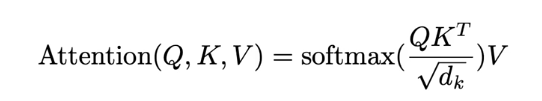

we didn't implement normalization   (dividing by the square root of head_size)

In [33]:
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
weights = q @ k.transpose(-2, -1)

In [34]:
k.var()

tensor(0.9006)

In [35]:
q.var()

tensor(1.0037)

In [36]:
weights.var()

tensor(15.9317)

^ variance around head_size

In [42]:
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
weights = q @ k.transpose(-2, -1) * head_size**-0.5

In [43]:
print(k.var())
print(q.var())
print(weights.var())

tensor(1.0632)
tensor(0.9891)
tensor(0.9755)


weights go into softmax so at initialization it is important for weights to be difused, we don't want the values to be too extreme because softmax would be too picky